# ================================================
# MULTIPLE LINEAR REGRESSION - Marketing ROI Analysis
# ===============================================

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
warnings.filterwarnings('ignore')
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline




# Loading data-set



In [13]:
# Loading dataset
df = pd.read_csv('multiple_sales_data.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nData Info:")
df.info()
print("\nMissing Values:\n", df.isnull().sum())

# Handle missing values
df = df.dropna()
print("\nShape after cleaning:", df.shape)

Dataset Shape: (572, 5)

First 5 rows:
        TV      Radio  Social Media Influencer       Sales
0     Low   3.518070      2.293790      Micro   55.261284
1     Low   7.756876      2.572287       Mega   67.574904
2    High  20.348988      1.227180      Micro  272.250108
3  Medium  20.108487      2.728374       Mega  195.102176
4    High  31.653200      7.776978       Nano  273.960377

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    object 
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), object(2)
memory usage: 22.5+ KB

Missing Values:
 TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

Shape after cleaning

##  Identify and Encode Categorical variable

In [15]:
# Identify the categorical column (adjust name if different)
cat_column = None
for col in df.columns:
    if df[col].dtype == 'object' or df[col].nunique() < 5:
        if df[col].str.contains('nano|micro|mega', case=False, na=False).any():
            cat_column = col
            break

if cat_column:
    print(f"✅ Categorical column found: '{cat_column}'")
else:
    cat_column = 'Influencer'
    print(f"Using assumed column name: '{cat_column}'")

# One-hot encoding
df_encoded = pd.get_dummies(df, columns=[cat_column], prefix='Influencer', drop_first=True)

print("\nNew columns after encoding:", df_encoded.columns.tolist())

✅ Categorical column found: 'Influencer'

New columns after encoding: ['TV', 'Radio', 'Social Media', 'Sales', 'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano']


#  Exploring data-set

##  Correlation Matrix

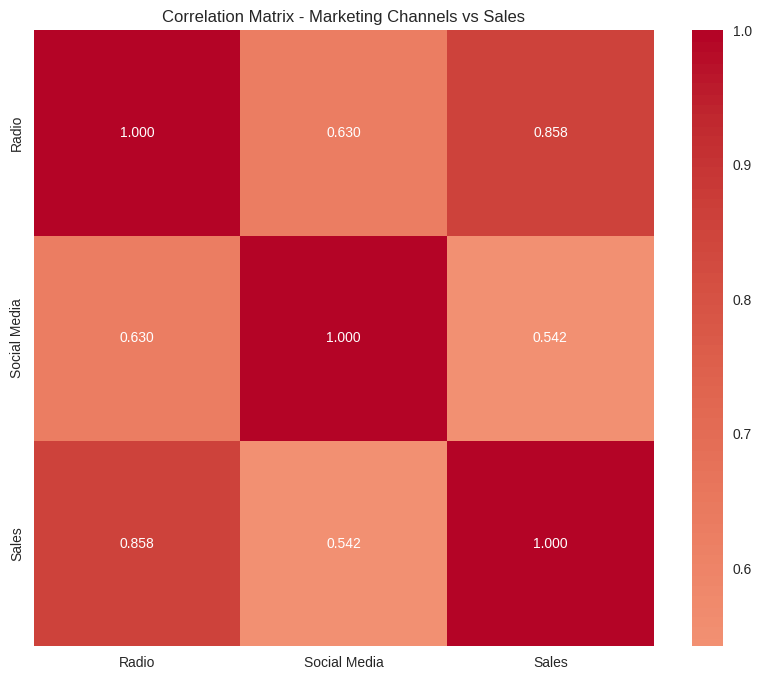

In [12]:
# Correlation Matrix
plt.figure(figsize=(10, 8))
# Select only numerical columns for correlation calculation
corr_matrix = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Correlation Matrix - Marketing Channels vs Sales')
plt.show()

##  Pairplot

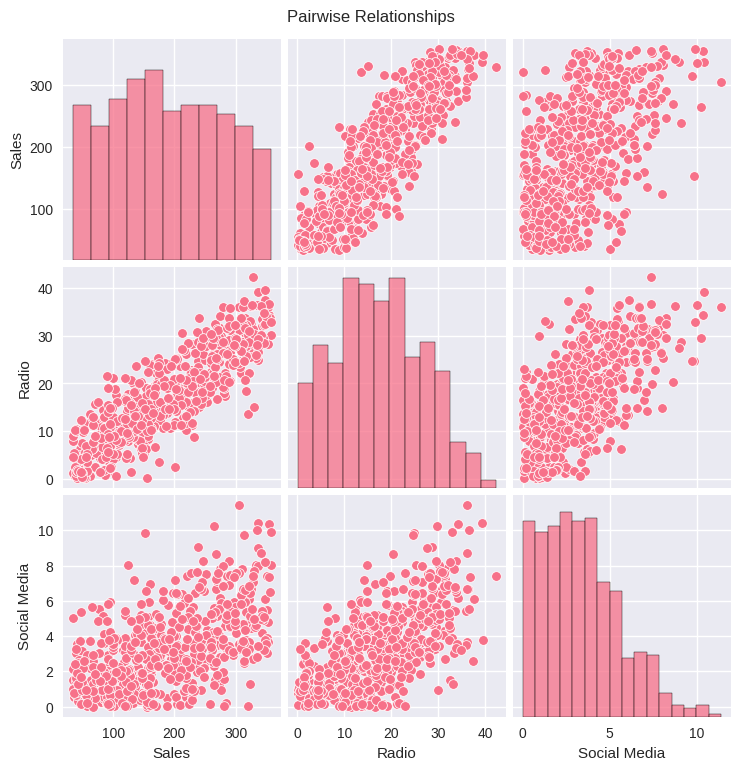

In [19]:
sns.pairplot(df[['Sales', 'TV', 'Radio', 'Social Media']])  # Adjust if needed
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()

##  Distribution of Sales

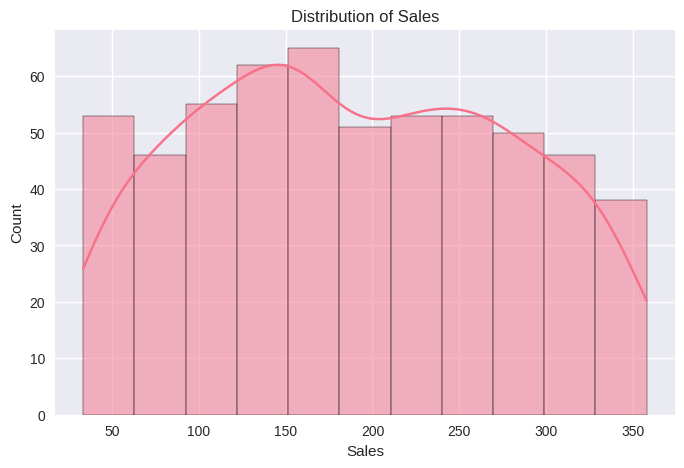

In [20]:
# Distribution of Sales
plt.figure(figsize=(8, 5))
sns.histplot(df['Sales'], kde=True)
plt.title('Distribution of Sales')
plt.show()

#  Prepare Data for Multiple Regression

In [30]:
# Define features and target

# Ensure 'Influencer' dummy variables are properly converted to integers in df_encoded
for col in ['Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano']:
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].astype(int)

# One-hot encode the 'TV' column
df_final_features = pd.get_dummies(df_encoded, columns=['TV'], drop_first=True)

# Select all feature columns (excluding 'Sales')
X_temp_df = df_final_features.drop('Sales', axis=1)

# Convert all feature columns to float and then to a NumPy array
# This ensures statsmodels receives purely numerical input (float).
X = X_temp_df.values.astype(float)

y = df_final_features['Sales']

# Add constant for intercept
X = sm.add_constant(X)

#  Build Multiple Linear Model

In [28]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     760.4
Date:                Sat, 13 Jun 2026   Prob (F-statistic):          1.82e-282
Time:                        18:12:25   Log-Likelihood:                -2713.4
No. Observations:                 572   AIC:                             5443.
Df Residuals:                     564   BIC:                             5478.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              217.4784      6.584  

#  Diagonistics

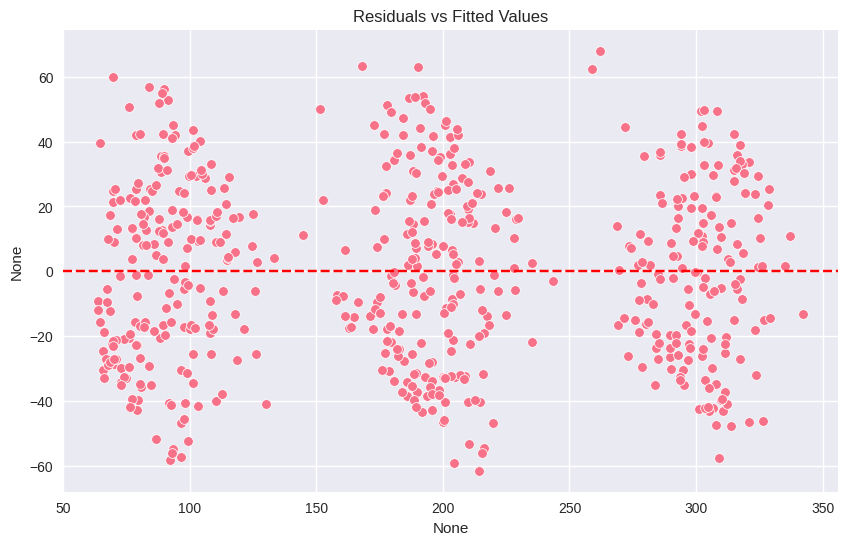

<Figure size 800x600 with 0 Axes>

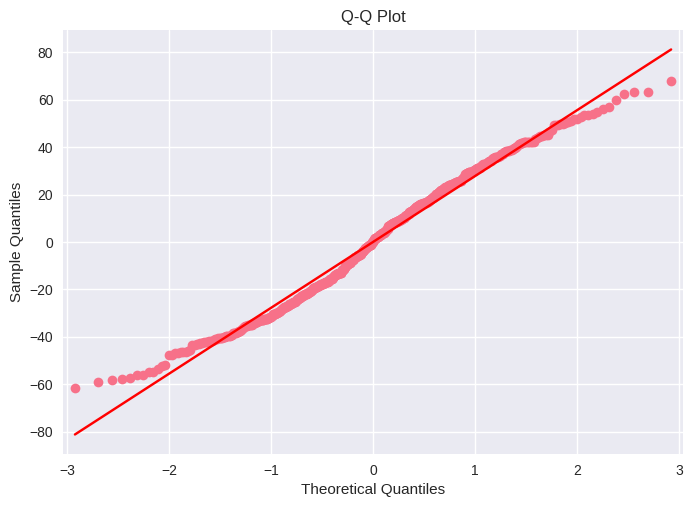

Breusch-Pagan p-value: 0.2879


In [31]:
fitted = model.fittedvalues
residuals = model.resid

# Residuals vs Fitted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.show()

# Q-Q Plot
plt.figure(figsize=(8, 6))
sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot')
plt.show()

# Breusch-Pagan Test
bp_test = het_breuschpagan(residuals, model.model.exog)
print(f"Breusch-Pagan p-value: {bp_test[1]:.4f}")

#  Multicollinearity Check

In [33]:
feature_names = X_temp_df.columns.tolist()
feature_names_with_const = ['const'] + feature_names

vif_data = pd.DataFrame()
vif_data["Feature"] = feature_names_with_const
vif_data["VIF"] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]

print("\nVariance Inflation Factors:")
print(vif_data.round(2))


Variance Inflation Factors:
            Feature    VIF
0             const  31.65
1             Radio   3.48
2      Social Media   1.67
3   Influencer_Mega   1.59
4  Influencer_Micro   1.62
5   Influencer_Nano   1.63
6            TV_Low   4.08
7         TV_Medium   2.23


#  Business Interpretation and Recomendations

In [34]:
print("\n" + "="*60)
print("BUSINESS INTERPRETATION")
print("="*60)

print(f"R-squared: {model.rsquared:.4f} | Adjusted R-squared: {model.rsquared_adj:.4f}\n")

coefficients = model.params
pvalues = model.pvalues

print("Impact of Each Marketing Channel:")
for var in ['TV', 'Radio', 'Social Media']:
    if var in coefficients.index:
        print(f"{var:15} : Coef = {coefficients[var]:8.4f} | p-value = {pvalues[var]:.4f} "
              f"{'***' if pvalues[var] < 0.01 else '**' if pvalues[var] < 0.05 else ''}")

print("\nInfluencer Impact:")
for col in coefficients.index:
    if 'Influencer_' in col:
        print(f"{col:20} : Coef = {coefficients[col]:8.4f} | p-value = {pvalues[col]:.4f}")

print(f"\nRecommendation: Focus budget on channels with highest positive & significant coefficients.")
print("Compare Nano vs Micro vs Mega influencers based on their dummy coefficients.")


BUSINESS INTERPRETATION
R-squared: 0.9042 | Adjusted R-squared: 0.9030

Impact of Each Marketing Channel:
Radio           : Coef =   2.9735 | p-value = 0.0000 ***
Social Media    : Coef =  -0.1391 | p-value = 0.8371 

Influencer Impact:
Influencer_Mega      : Coef =   2.4948 | p-value = 0.4714
Influencer_Micro     : Coef =   2.9391 | p-value = 0.3846
Influencer_Nano      : Coef =   0.8015 | p-value = 0.8107

Recommendation: Focus budget on channels with highest positive & significant coefficients.
Compare Nano vs Micro vs Mega influencers based on their dummy coefficients.
